# Medical Diagnosis Support using Decision Trees
## Breast Cancer Wisconsin (Diagnostic) Dataset

### MDI3003 - Advanced Predictive Analytics

---

## Objective

Develop an interpretable machine learning pipeline capable of classifying breast tumors as **Malignant** or **Benign** using Decision Tree based models while following industry-standard machine learning practices.

The project emphasizes:

- Data quality assessment
- Leakage-free preprocessing
- Explainable AI
- Model reproducibility
- Hyperparameter optimization
- Clinical error analysis
- Responsible AI practices

---

## Educational Disclaimer

This notebook is developed solely for educational and research purposes.

The resulting predictive models are **NOT** clinically validated and must **NOT** be used for diagnosis, treatment planning, patient triage, or any real-world healthcare decision making.

The predictions generated by this notebook only reproduce patterns learned from a public benchmark dataset.

# 1. Business Understanding

## Problem Statement

Early detection of breast cancer significantly improves patient survival rates. This project aims to develop an interpretable binary classification model capable of predicting whether a breast tumor is malignant or benign based on numerical characteristics extracted from digitized fine-needle aspirate (FNA) images.

Unlike black-box models, Decision Trees provide transparent decision rules that can be inspected and interpreted, making them useful as baseline explainable models in healthcare research.

---

## Prediction Task

**Observation Unit**

Each row represents one breast tumor sample obtained through Fine Needle Aspiration (FNA).

**Target Variable**

Breast Cancer Diagnosis

**Positive Class**

Malignant Tumor (Encoded as 1)

**Negative Class**

Benign Tumor (Encoded as 0)

**Prediction Time**

All predictor variables are assumed to be available before the diagnosis is confirmed.

---

## Intended Use

Educational predictive analytics demonstrating interpretable classification.

## Out of Scope

This model should never be used for:

- Medical diagnosis
- Treatment recommendation
- Clinical decision support
- Patient risk assessment

# 2. Environment Setup

This section imports all required libraries, configures visualization settings, fixes random seeds for reproducibility, and records software versions.

In [1]:
# ==========================================
# Standard Library
# ==========================================

import os
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

# ==========================================
# Data Manipulation
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Scikit-Learn
# ==========================================

from sklearn.datasets import load_breast_cancer

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_context("talk")

# ==========================================
# Reproducibility
# ==========================================

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ==========================================
# Version Information
# ==========================================

import platform
import sklearn

print("="*60)
print("Environment Information")
print("="*60)

print(f"Python Version      : {platform.python_version()}")
print(f"Pandas Version      : {pd.__version__}")
print(f"Numpy Version       : {np.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Random State        : {RANDOM_STATE}")

Environment Information
Python Version      : 3.10.0
Pandas Version      : 2.3.2
Numpy Version       : 2.2.6
Scikit-Learn Version: 1.7.2
Random State        : 42


# 3. Dataset Loading

The Breast Cancer Wisconsin (Diagnostic) dataset is directly available in Scikit-Learn.

Dataset characteristics:

- 569 observations
- 30 numerical features
- Binary classification
- No missing values
- Suitable for interpretable Decision Tree modeling

For this project, **Malignant** tumors are encoded as the positive class (1).

In [2]:
# ==========================================
# Load Dataset
# ==========================================

raw_data = load_breast_cancer(as_frame=True)

X = raw_data.data.copy()
y = raw_data.target.copy()

In [3]:
# Convert target

target_mapping = {
    0: 1,   # Malignant
    1: 0    # Benign
}

y = y.map(target_mapping)

y.name = "Diagnosis"

dataset = X.copy()
dataset["Diagnosis"] = y

dataset.head()

print("="*60)
print("Dataset Summary")
print("="*60)

print(f"Rows               : {dataset.shape[0]}")
print(f"Columns            : {dataset.shape[1]}")
print(f"Features           : {X.shape[1]}")
print(f"Target Classes     : {y.nunique()}")

print("\nTarget Mapping")
print("1 -> Malignant")
print("0 -> Benign")

print("\nClass Distribution")

display(y.value_counts())

Dataset Summary
Rows               : 569
Columns            : 31
Features           : 30
Target Classes     : 2

Target Mapping
1 -> Malignant
0 -> Benign

Class Distribution


Diagnosis
0    357
1    212
Name: count, dtype: int64

# 4. Data Understanding

Before training any predictive model, it is essential to understand the characteristics of the dataset.

This section performs a comprehensive data audit including:

- Dataset structure
- Data types
- Statistical profiling
- Target distribution
- Missing values
- Duplicate observations
- Constant features
- Feature distributions
- Outlier analysis
- Correlation analysis
- Multicollinearity
- Feature relationships

The purpose of this analysis is to identify potential data quality issues, understand feature behaviour, and guide preprocessing decisions while avoiding unnecessary transformations.

In [4]:
print("="*70)
print("Dataset Shape")
print("="*70)

print(f"Rows      : {dataset.shape[0]}")
print(f"Columns   : {dataset.shape[1]}")
print(f"Features  : {X.shape[1]}")
print(f"Target    : Diagnosis")

Dataset Shape
Rows      : 569
Columns   : 31
Features  : 30
Target    : Diagnosis


In [5]:
dataset.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1


In [6]:
dataset.sample(5, random_state=RANDOM_STATE)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
204,12.4700,18.6000,81.0900,481.9000,0.0997,0.1058,0.0800,0.0382,0.1925,0.0637,0.3961,1.0440,2.4970,30.2900,0.0070,0.0191,0.0270,0.0104,0.0178,0.0036,14.9700,24.6400,96.0500,677.9000,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,0
70,18.9400,21.3100,123.6000,1130.0000,0.0901,0.1029,0.1080,0.0795,0.1582,0.0546,0.7888,0.7975,5.4860,96.0500,0.0044,0.0165,0.0227,0.0137,0.0139,0.0017,24.8600,26.5800,165.9000,1866.0000,0.1193,0.2336,0.2687,0.1789,0.2551,0.0659,1
131,15.4600,19.4800,101.7000,748.9000,0.1092,0.1223,0.1466,0.0809,0.1931,0.0580,0.4743,0.7859,3.0940,48.3100,0.0062,0.0148,0.0281,0.0109,0.0140,0.0025,19.2600,26.0000,124.9000,1156.0000,0.1546,0.2394,0.3791,0.1514,0.2837,0.0802,1
431,12.4000,17.6800,81.4700,467.8000,0.1054,0.1316,0.0774,0.0280,0.1811,0.0710,0.1767,1.4600,2.2040,15.4300,0.0100,0.0330,0.0486,0.0117,0.0219,0.0060,12.8800,22.9100,89.6100,515.8000,0.1450,0.2629,0.2403,0.0737,0.2556,0.0936,0
540,11.5400,14.4400,74.6500,402.9000,0.0998,0.1120,0.0674,0.0259,0.1818,0.0678,0.2784,1.7680,1.6280,20.8600,0.0121,0.0411,0.0555,0.0149,0.0184,0.0055,12.2600,19.6800,78.7800,457.8000,0.1345,0.2118,0.1797,0.0692,0.2329,0.0813,0


### Observation

- The dataset contains numerical predictor variables only.
- Each row represents one patient sample.
- The target variable is binary.
- No obvious identifier columns are present.

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
dtype_table = (
    dataset
    .dtypes
    .reset_index()
)

dtype_table.columns = ["Feature","Data Type"]

display(dtype_table)

,Feature,Data Type
0,mean radius,float64
1,mean texture,float64
2,mean perimeter,float64
3,mean area,float64
4,mean smoothness,float64
5,mean compactness,float64
6,mean concavity,float64
7,mean concave points,float64
8,mean symmetry,float64
9,mean fractal dimension,float64


### Observation

- All predictor variables are continuous numerical measurements.
- No categorical variables are present.
- No datetime or identifier features exist.
- Therefore, no categorical encoding is required.

In [9]:
summary = dataset.describe().T

summary
summary["median"] = dataset.median()

summary["variance"] = dataset.var()

summary["skewness"] = dataset.skew()

summary["kurtosis"] = dataset.kurt()

summary

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
mean radius,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100,13.3700,12.4189,0.9424,0.8455
mean texture,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800,18.8400,18.4989,0.6504,0.7583
mean perimeter,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000,86.2400,590.4405,0.9907,0.9722
mean area,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000,551.1000,123843.5543,1.6457,3.6523
mean smoothness,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634,0.0959,0.0002,0.4563,0.8560
mean compactness,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454,0.0926,0.0028,1.1901,1.6501
mean concavity,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268,0.0615,0.0064,1.4012,1.9986
mean concave points,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012,0.0335,0.0015,1.1712,1.0666
mean symmetry,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040,0.1792,0.0008,0.7256,1.2879
mean fractal dimension,569.0000,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974,0.0615,0.0000,1.3045,3.0059


### Observation

The summary statistics reveal substantial variation in feature ranges.

Several variables exhibit noticeable skewness and high kurtosis, indicating that feature distributions are not perfectly Gaussian. Decision Tree based algorithms are robust to non-normality; therefore, no transformation is immediately required.

In [10]:
target_counts = y.value_counts().sort_index()

target_percent = (
    y.value_counts(normalize=True)
      .sort_index()*100
)

display(pd.DataFrame({
    "Count":target_counts,
    "Percentage":target_percent.round(2)
}))

,Count,Percentage
Diagnosis,,
0,357,62.7400
1,212,37.2600


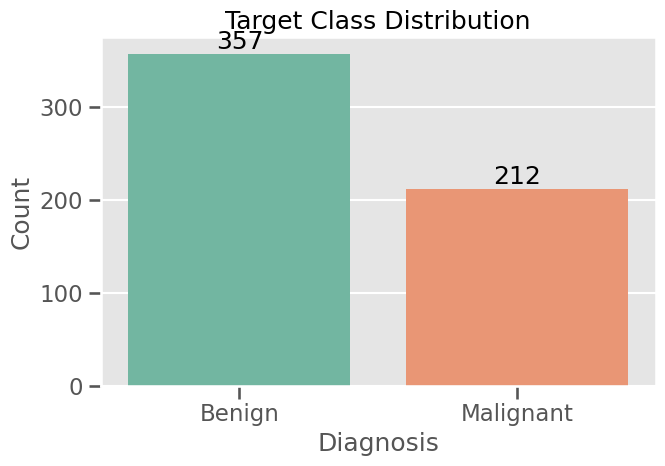

In [11]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x=y,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks([0,1],["Benign","Malignant"])

plt.title("Target Class Distribution")

plt.xlabel("Diagnosis")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

### Observation

The dataset exhibits a relatively balanced class distribution, although benign cases are more frequent than malignant cases.

Since the imbalance is not severe, oversampling techniques such as SMOTE are unnecessary. However, class weighting will still be evaluated during model development.

In [12]:
missing = pd.DataFrame({

    "Missing Values":dataset.isnull().sum(),

    "Percentage":(
        dataset.isnull().mean()*100
    )

})

missing.sort_values(
    by="Missing Values",
    ascending=False
).head()

,Missing Values,Percentage
mean radius,0,0.0000
mean texture,0,0.0000
mean perimeter,0,0.0000
mean area,0,0.0000
mean smoothness,0,0.0000


### Observation

No missing values are present in the dataset.

Although imputation is unnecessary for this dataset, the modelling pipeline will still include an imputer to maintain a reusable and production-ready workflow.

In [13]:
duplicates = dataset.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")
if duplicates>0:
    display(dataset[dataset.duplicated()])

Duplicate Rows : 0


### Observation

No duplicate observations are detected.

Therefore, no duplicate removal is required.

In [14]:
constant = [
    c
    for c in X.columns
    if X[c].nunique()==1
]

constant

[]

In [15]:
quasi = []

for col in X.columns:

    dominant = X[col].value_counts(normalize=True).iloc[0]

    if dominant>0.99:

        quasi.append(col)

quasi

[]

### Observation

No constant or quasi-constant features are present.

All variables contribute information to the predictive task.

In [16]:
def plot_feature_distributions(df, cols, target):

    n_cols = 3

    n_rows = int(np.ceil(len(cols)/n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18,5*n_rows)
    )

    axes = axes.flatten()

    for ax,col in zip(axes,cols):

        sns.histplot(

            data=df,

            x=col,

            hue=target,

            kde=True,

            stat="density",

            common_norm=False,

            ax=ax

        )

        ax.set_title(col)

    for ax in axes[len(cols):]:

        ax.remove()

    plt.tight_layout()

    plt.show()

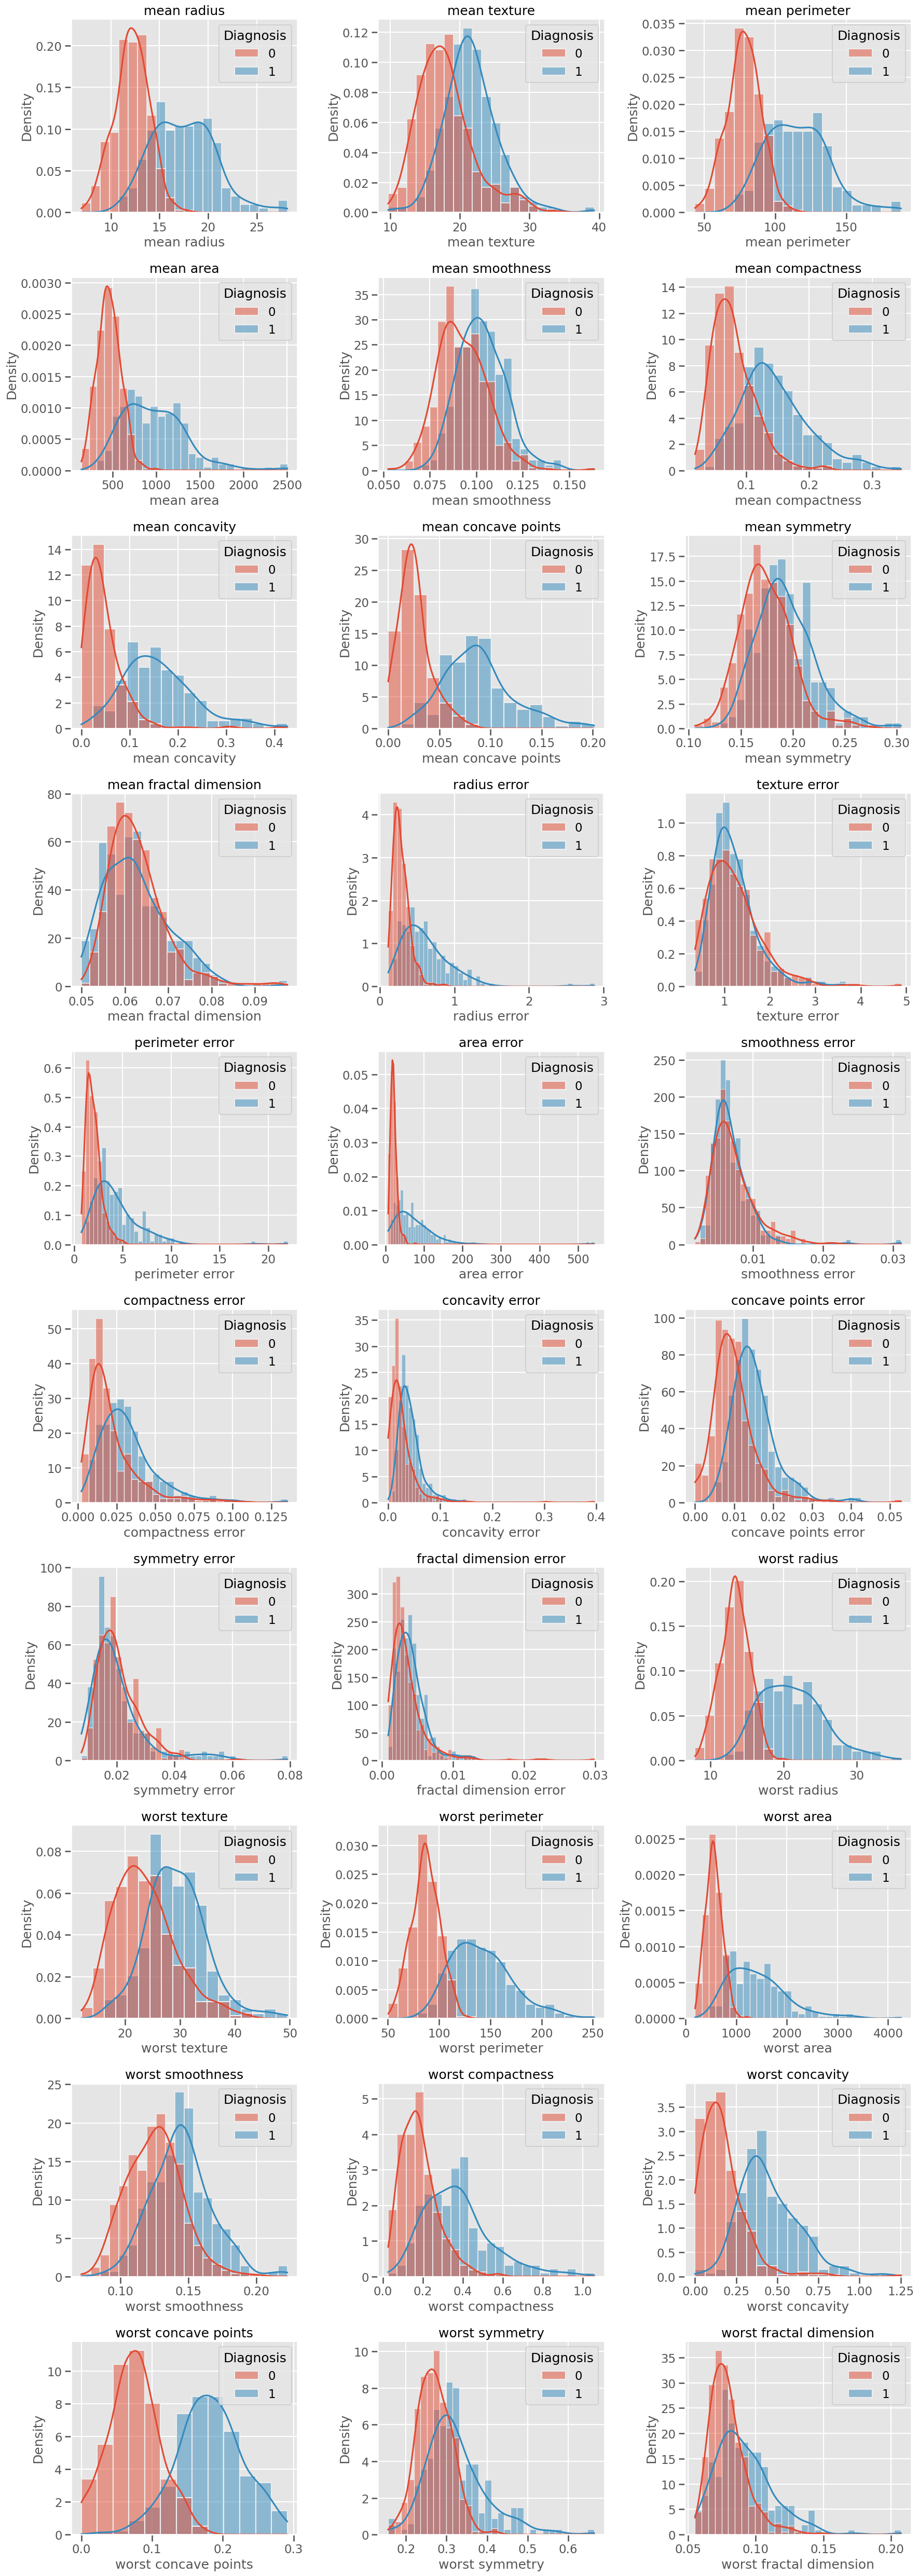

In [17]:
plot_feature_distributions(

    dataset,

    X.columns,

    "Diagnosis"

)

### Observation

Several features demonstrate clear separation between malignant and benign tumors.

Features such as:

- worst radius
- worst perimeter
- worst concavity
- mean concavity
- mean radius

appear highly discriminative and are likely to contribute significantly during tree construction.

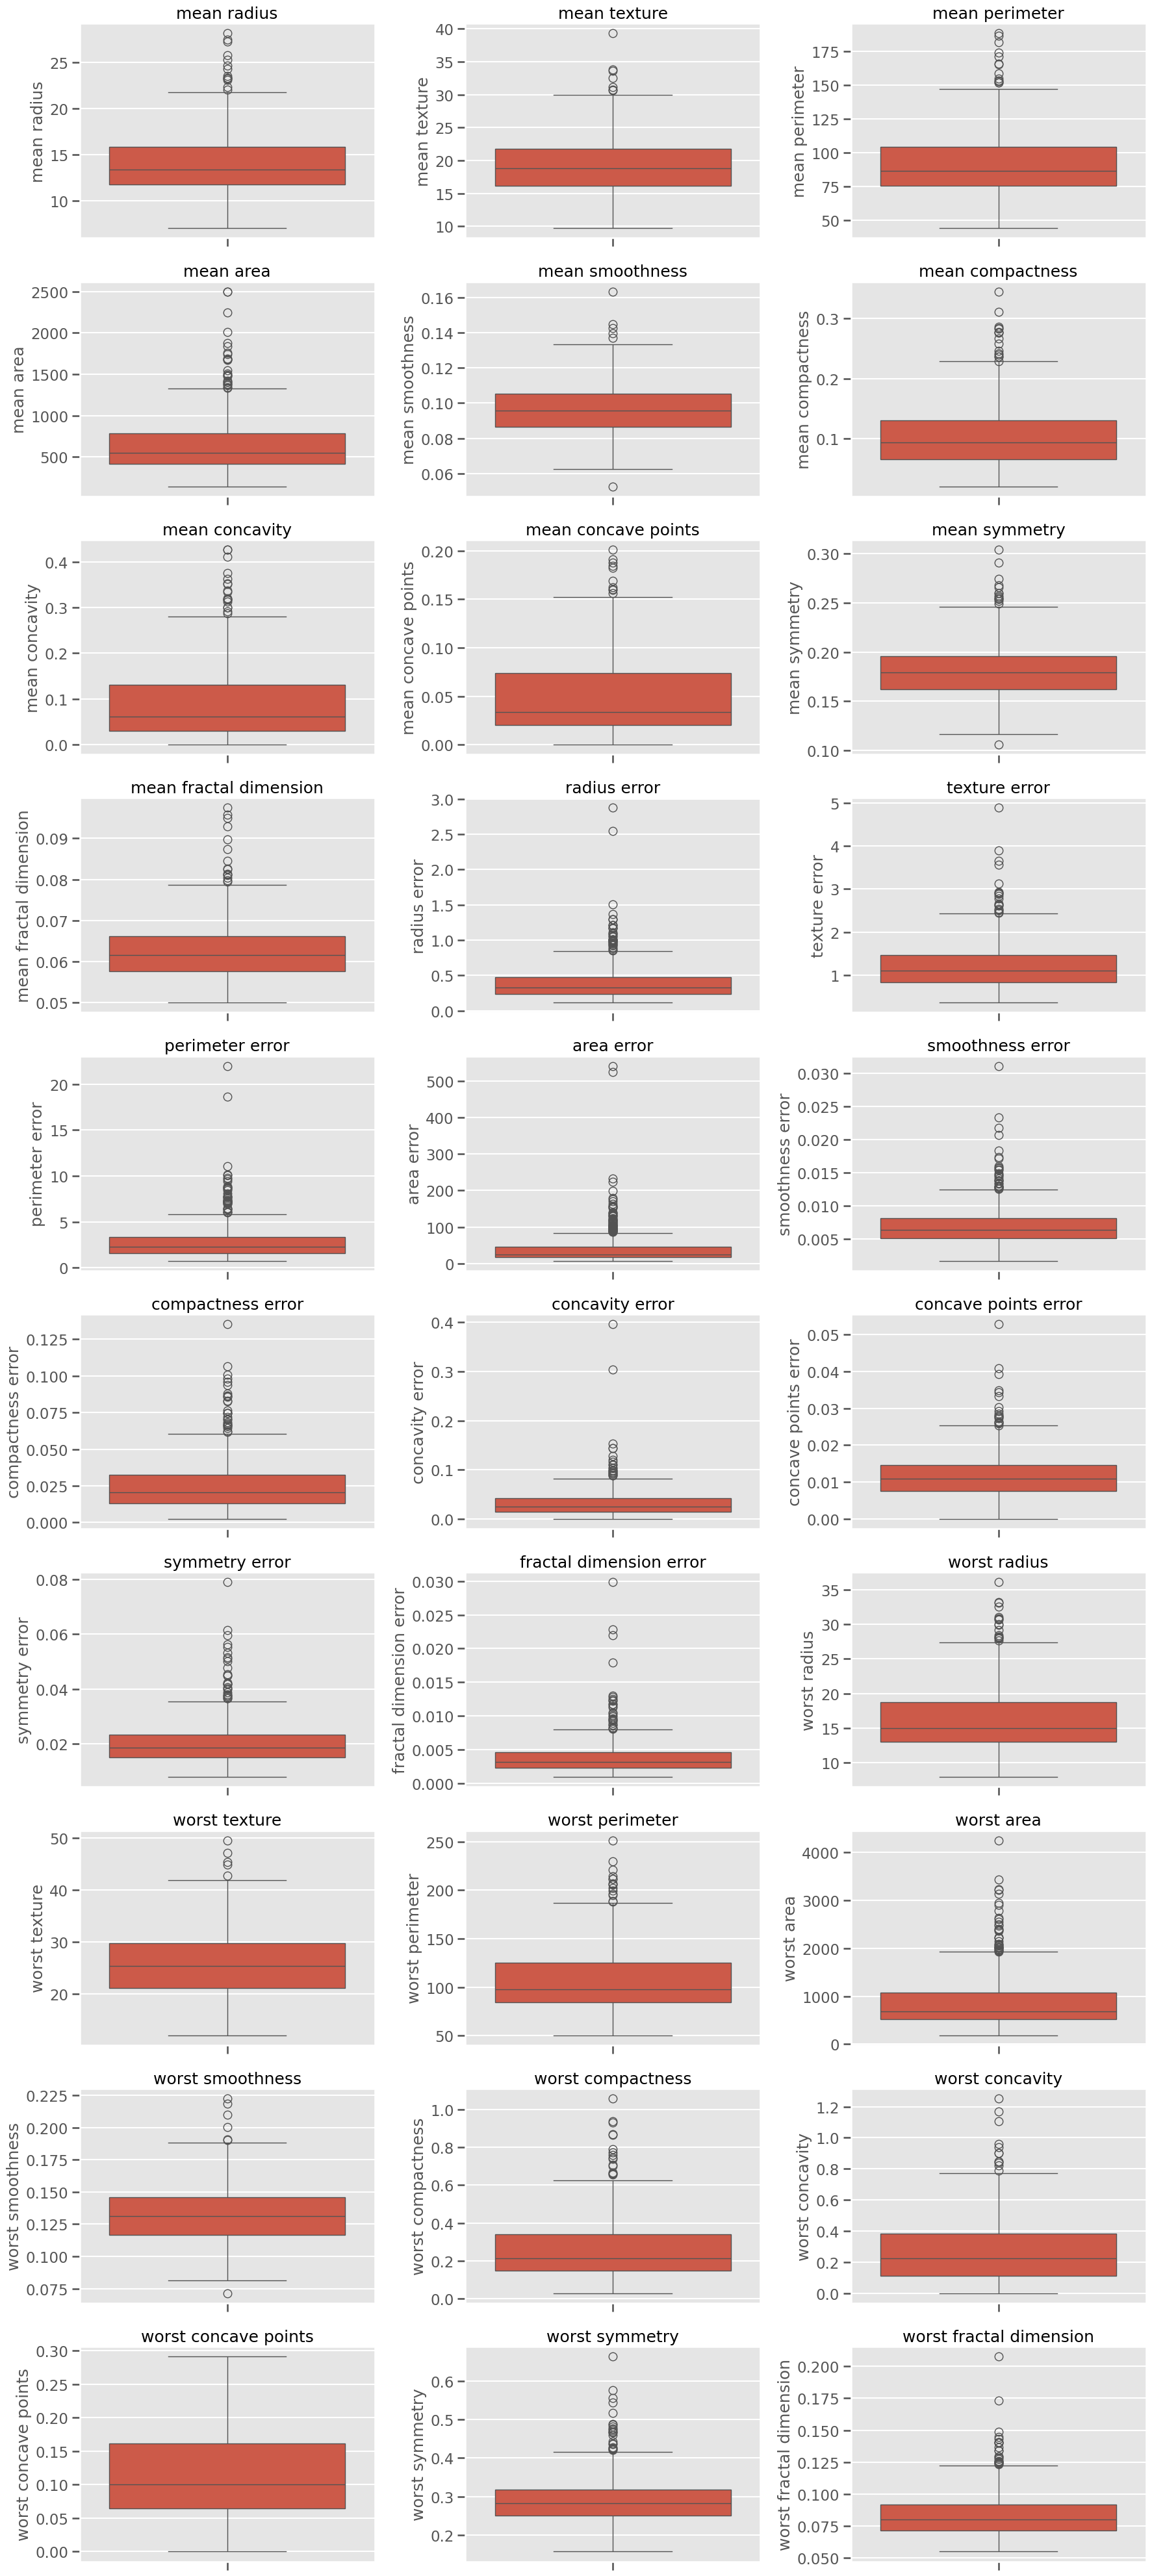

In [18]:
fig, axes = plt.subplots(10,3,figsize=(18,40))

axes = axes.flatten()

for ax,col in zip(axes,X.columns):

    sns.boxplot(

        y=dataset[col],

        ax=ax

    )

    ax.set_title(col)

for ax in axes[len(X.columns):]:

    ax.remove()

plt.tight_layout()

plt.show()

### Observation

Several numerical variables contain apparent outliers.

Decision Tree algorithms partition observations using thresholds rather than distance metrics and are therefore considerably less sensitive to outliers than linear models or nearest-neighbour methods.

Consequently, outlier removal is not performed.

In [19]:
shape = pd.DataFrame({

    "Skewness":X.skew(),

    "Kurtosis":X.kurt()

})

shape.sort_values(
    by="Skewness",
    ascending=False
)

,Skewness,Kurtosis
area error,5.4472,49.2091
concavity error,5.1105,48.8614
fractal dimension error,3.9240,26.2808
perimeter error,3.4436,21.4019
radius error,3.0886,17.6867
smoothness error,2.3145,10.4698
symmetry error,2.1951,7.8961
compactness error,1.9022,5.1063
worst area,1.8594,4.3964
worst fractal dimension,1.6626,5.2446


### Observation

Many variables exhibit positive skewness.

Since Decision Trees are invariant to monotonic transformations and do not assume Gaussian distributions, no logarithmic or Box-Cox transformation is required.

# 5. Advanced Exploratory Data Analysis

The objective of this section is to investigate relationships between predictor variables, identify multicollinearity, examine feature relevance, and detect potential data leakage before model development.

These analyses guide feature selection, preprocessing strategy, and model interpretation while maintaining a leakage-safe workflow.

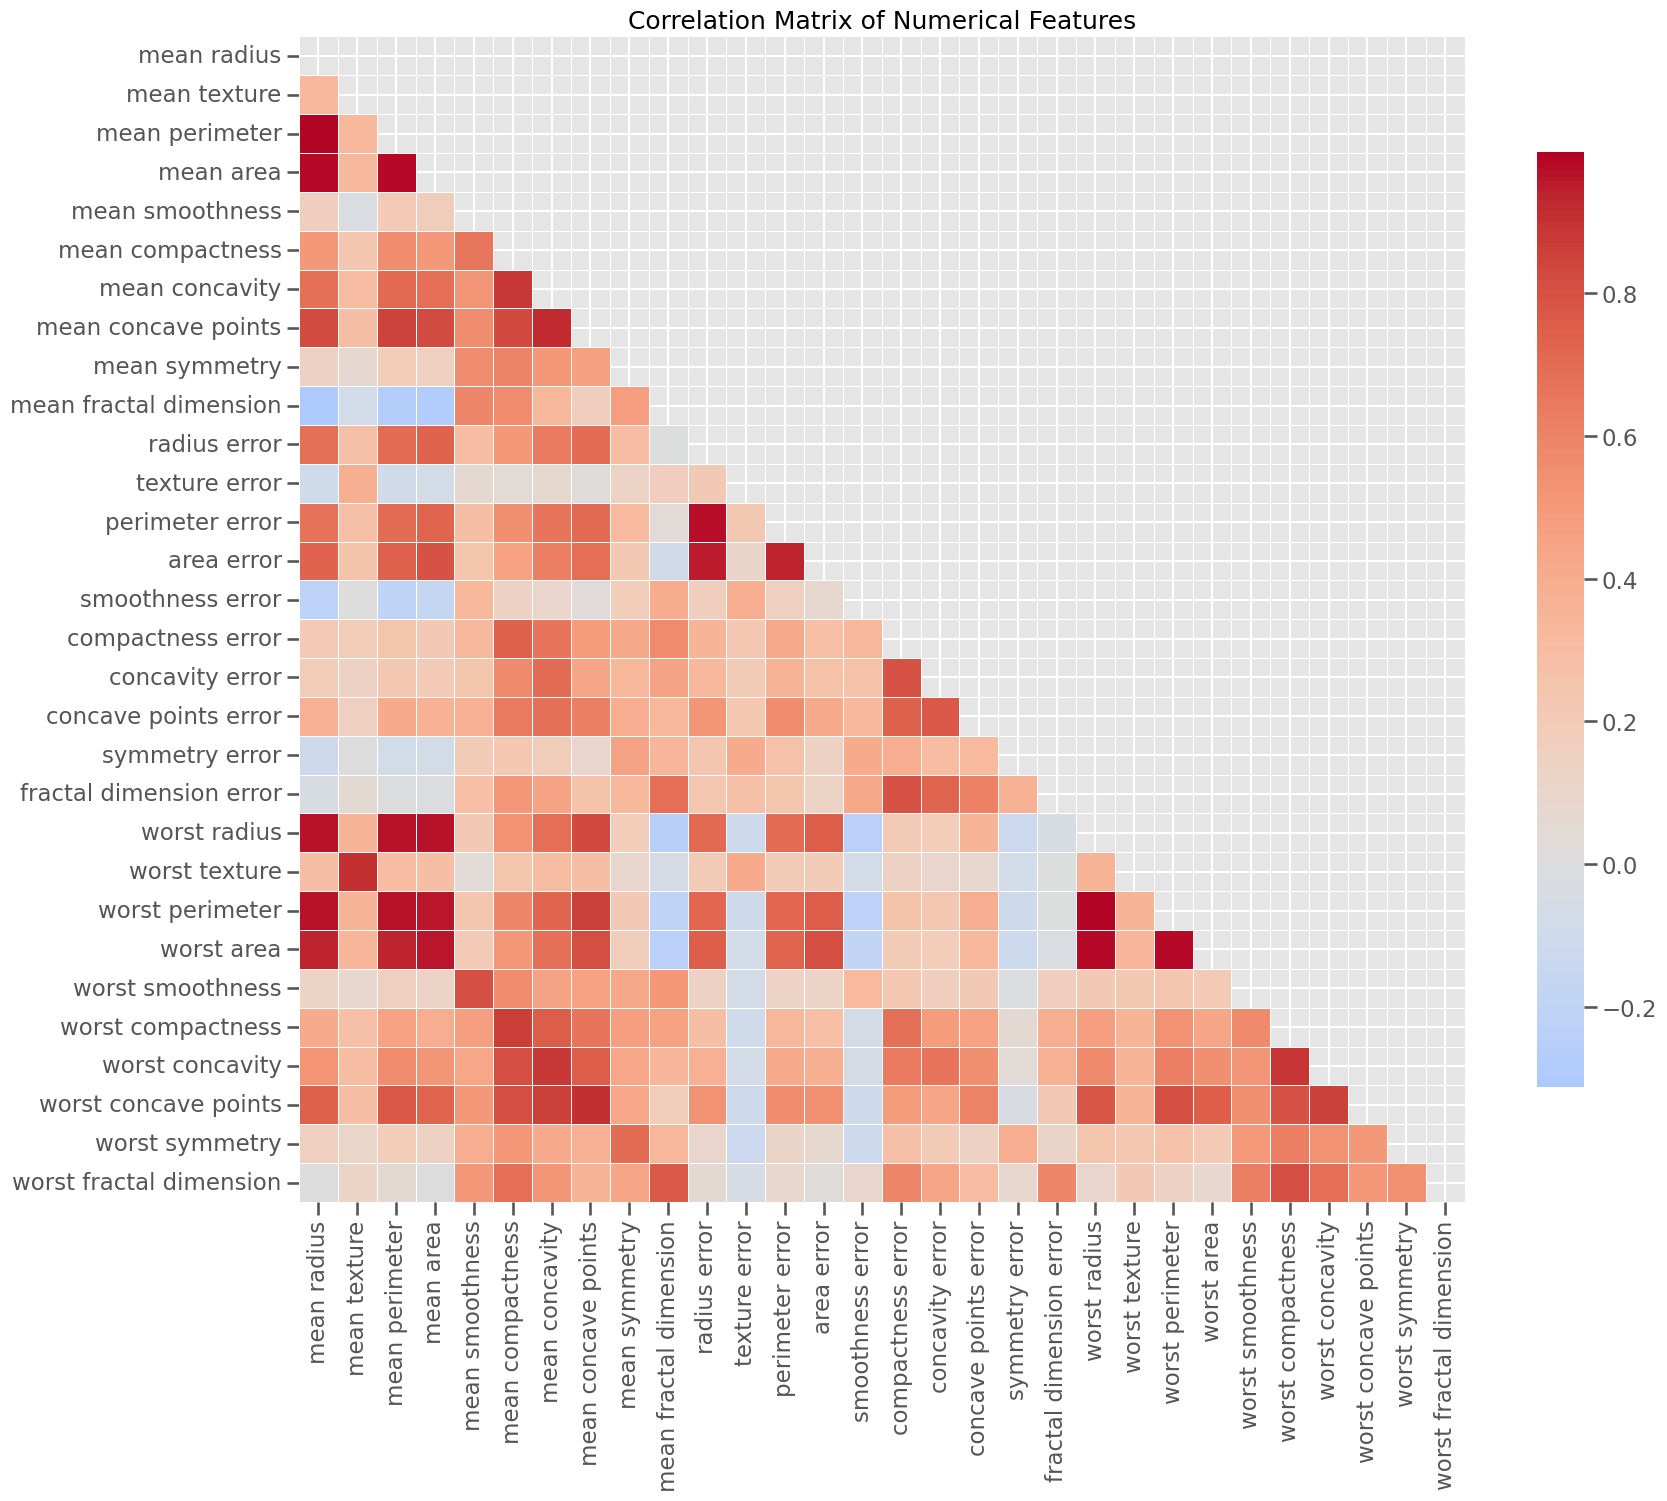

In [20]:
corr_matrix = X.corr()

plt.figure(figsize=(18,15))

mask = np.triu(np.ones_like(corr_matrix))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

### Observation

The correlation matrix reveals several highly correlated feature groups.

Strong correlations are expected because multiple measurements are derived from the same tumour characteristics (radius, perimeter, area, texture, etc.).

Decision Tree models are generally robust to multicollinearity; therefore no feature removal is performed solely based on correlation.

In [21]:
corr = X.corr().abs()

upper = corr.where(
    np.triu(np.ones(corr.shape),k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .reset_index()
)

high_corr.columns = ["Feature A","Feature B","Correlation"]

high_corr = high_corr[
    high_corr["Correlation"]>=0.85
].sort_values(
    by="Correlation",
    ascending=False
)

display(high_corr)

,Feature A,Feature B,Correlation
1,mean radius,mean perimeter,0.9979
391,worst radius,worst perimeter,0.9937
2,mean radius,mean area,0.9874
57,mean perimeter,mean area,0.9865
392,worst radius,worst area,0.9840
407,worst perimeter,worst area,0.9776
246,radius error,perimeter error,0.9728
76,mean perimeter,worst perimeter,0.9704
19,mean radius,worst radius,0.9695
74,mean perimeter,worst radius,0.9695


### Observation

Several feature pairs exhibit correlation coefficients above 0.90.

These variables capture closely related physical characteristics and therefore contain overlapping information.

Since tree-based models automatically select informative split variables, feature elimination is unnecessary.

In [22]:
corr_target = dataset.corr()["Diagnosis"][:-1]

corr_target = (
    corr_target
    .sort_values(
        key=abs,
        ascending=False
    )
)

corr_target

worst concave points       0.7936
worst perimeter            0.7829
mean concave points        0.7766
worst radius               0.7765
mean perimeter             0.7426
worst area                 0.7338
mean radius                0.7300
mean area                  0.7090
mean concavity             0.6964
worst concavity            0.6596
mean compactness           0.5965
worst compactness          0.5910
radius error               0.5671
perimeter error            0.5561
area error                 0.5482
worst texture              0.4569
worst smoothness           0.4215
worst symmetry             0.4163
mean texture               0.4152
concave points error       0.4080
mean smoothness            0.3586
mean symmetry              0.3305
worst fractal dimension    0.3239
compactness error          0.2930
concavity error            0.2537
fractal dimension error    0.0780
smoothness error          -0.0670
mean fractal dimension    -0.0128
texture error             -0.0083
symmetry error

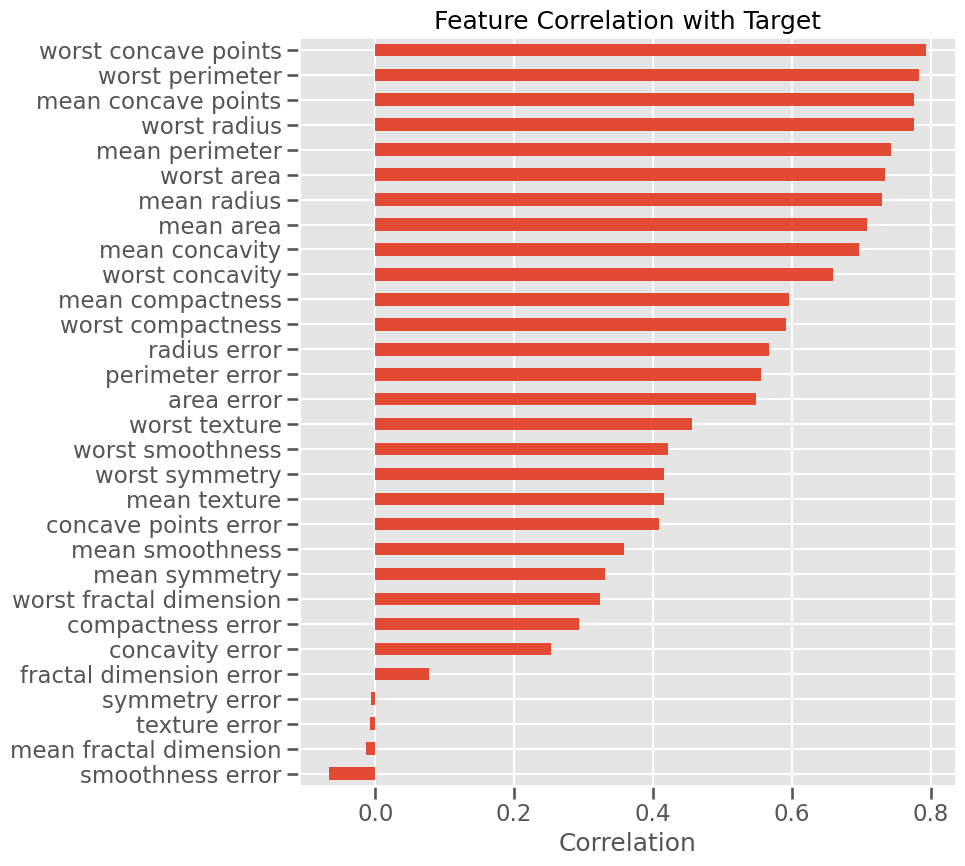

In [23]:
plt.figure(figsize=(10,9))

corr_target.sort_values().plot.barh()

plt.title("Feature Correlation with Target")

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

### Observation

Features such as:

- worst radius
- worst perimeter
- worst concavity
- mean concavity
- mean perimeter

show the strongest linear association with tumour diagnosis.

Although correlation alone does not determine model importance, these variables are expected to appear near the top of the decision tree.

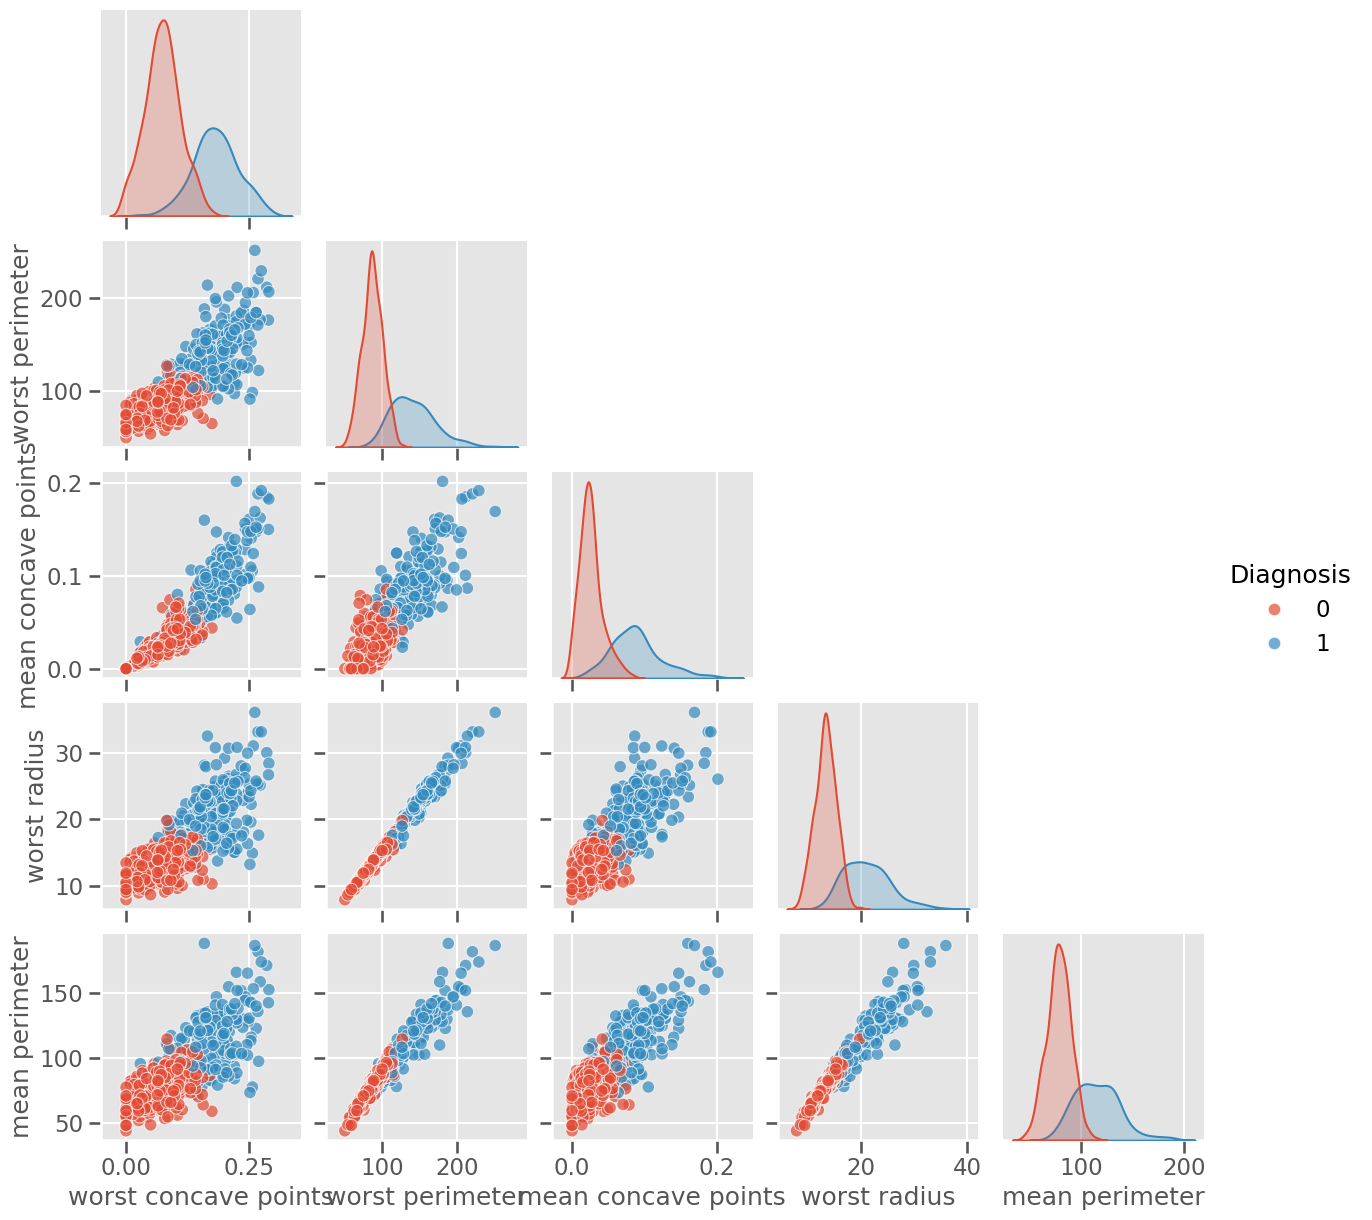

In [24]:
top_features = corr_target.abs().head(5).index.tolist()

pair_df = dataset[top_features + ["Diagnosis"]]

sns.pairplot(

    pair_df,

    hue="Diagnosis",

    diag_kind="kde",

    corner=True,

    plot_kws={"alpha":0.7}

)

plt.show()

### Observation

The pairwise relationships demonstrate substantial separation between benign and malignant samples.

Several feature combinations appear to be almost linearly separable, indicating that relatively shallow Decision Trees may already achieve strong predictive performance.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [

    variance_inflation_factor(

        X.values,

        i

    )

    for i in range(X.shape[1])

]

vif.sort_values(

    by="VIF",

    ascending=False

).head(15)

,Feature,VIF
0,mean radius,63306.1720
2,mean perimeter,58123.5861
20,worst radius,9674.7426
22,worst perimeter,4487.7813
3,mean area,1287.2623
23,worst area,1138.7593
9,mean fractal dimension,629.6799
29,worst fractal dimension,423.3967
4,mean smoothness,393.3982
24,worst smoothness,375.5972


### Observation

Several variables exhibit extremely high VIF values, confirming strong multicollinearity.

This is expected because many features represent related geometric measurements extracted from the same tumour image.

Decision Trees are considerably less affected by multicollinearity than linear regression models; therefore no corrective action is necessary.

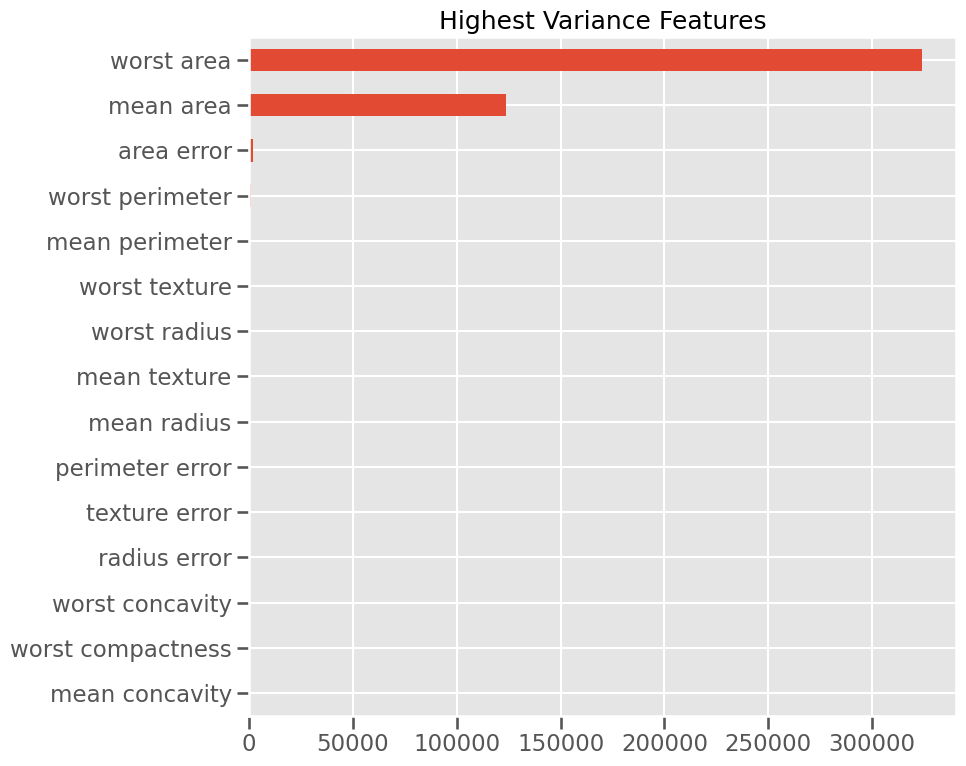

In [26]:
feature_variance = X.var().sort_values(
    ascending=False
)

feature_variance.head(15)
plt.figure(figsize=(10,8))

feature_variance.head(15).sort_values().plot.barh()

plt.title("Highest Variance Features")

plt.tight_layout()

plt.show()

### Observation

Feature variance differs considerably across variables.

Since Decision Trees are invariant to monotonic scaling, high variance does not adversely affect model performance and no standardisation is required.

In [27]:
audit = pd.DataFrame({

    "Missing":X.isna().sum(),

    "Unique":X.nunique(),

    "Correlation with Target":corr_target,

    "Potential Leakage":"No"

})

audit.head()

,Missing,Unique,Correlation with Target,Potential Leakage
area error,0,528,0.5482,No
compactness error,0,541,0.2930,No
concave points error,0,507,0.4080,No
concavity error,0,533,0.2537,No
fractal dimension error,0,545,0.0780,No


In [28]:
print("="*60)

print("Leakage Audit")

print("="*60)

print("Identifier Columns :",0)

print("Duplicate Rows     :",dataset.duplicated().sum())

print("Missing Values     :",dataset.isna().sum().sum())

print("Target Leakage     : None Identified")

Leakage Audit
Identifier Columns : 0
Duplicate Rows     : 0
Missing Values     : 0
Target Leakage     : None Identified


### Observation

The dataset contains no identifiers, timestamps, post-diagnosis variables, or outcome-derived attributes.

All predictor variables are assumed to be available before the prediction task, making the dataset suitable for supervised learning without target leakage.

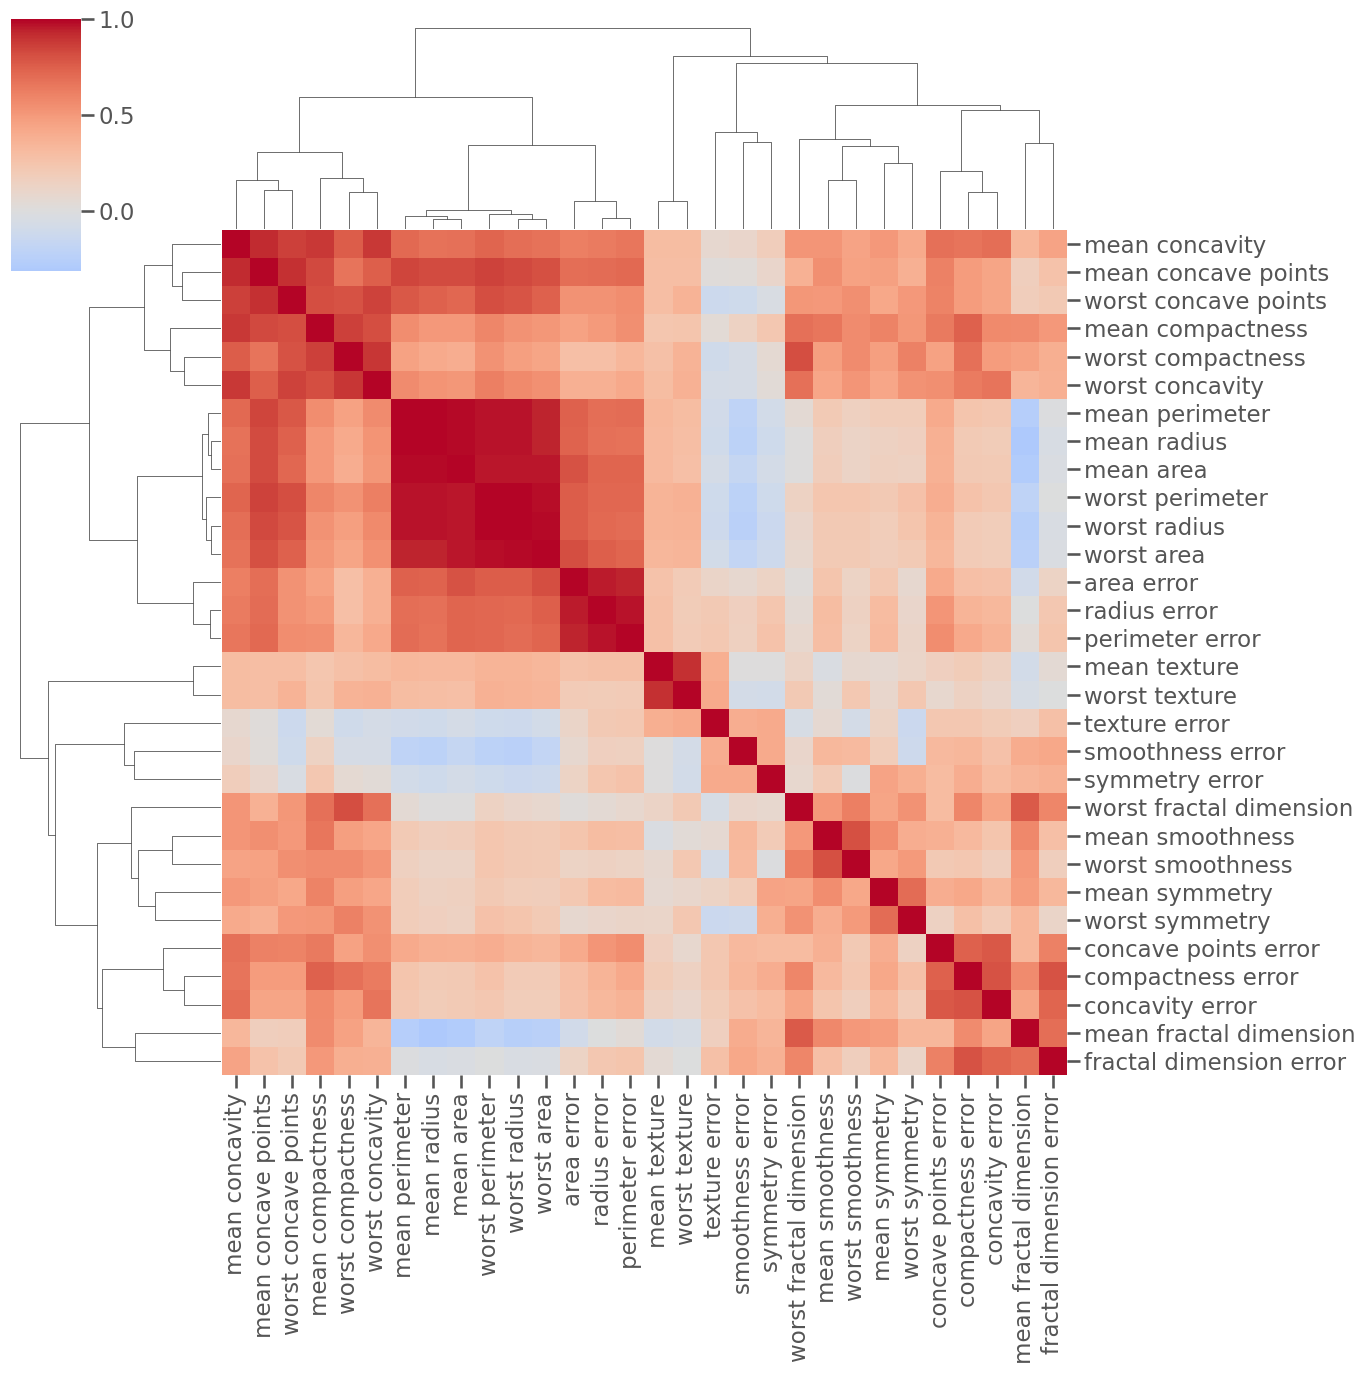

In [29]:
sns.clustermap(

    corr_matrix,

    figsize=(14,14),

    cmap="coolwarm",

    center=0

)

plt.show()

### Observation

Hierarchical clustering reveals several coherent groups of related measurements, particularly among radius, perimeter, area, and concavity variables.

These feature clusters provide additional evidence that multiple variables describe similar biological properties.

In [30]:
eda_summary = pd.DataFrame({

    "Finding":[

        "Missing Values",

        "Duplicate Rows",

        "Constant Features",

        "Categorical Variables",

        "Target Leakage",

        "Class Imbalance",

        "Strong Correlation",

        "Outliers",

        "Scaling Required"

    ],

    "Result":[

        "None",

        dataset.duplicated().sum(),

        len(constant),

        "None",

        "None Detected",

        "Mild",

        "Present",

        "Present",

        "No"

    ]

})

eda_summary

,Finding,Result
0,Missing Values,None
1,Duplicate Rows,0
2,Constant Features,0
3,Categorical Variables,None
4,Target Leakage,None Detected
5,Class Imbalance,Mild
6,Strong Correlation,Present
7,Outliers,Present
8,Scaling Required,No


# 6. Data Preparation

The exploratory analysis indicated that the dataset contains only numerical variables with no missing values, duplicates, or categorical features.

Although preprocessing requirements are minimal for this dataset, a complete Scikit-Learn pipeline will be constructed to ensure:

- reproducibility
- leakage prevention
- compatibility with future datasets
- production-ready model deployment

The test set is created before any model training or hyperparameter tuning and remains untouched until the final evaluation.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("="*60)
print("Dataset Split")
print("="*60)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print(f"Training Features: {X_train.shape[1]}")

Dataset Split
Training Samples : 455
Testing Samples  : 114
Training Features: 30


In [32]:
split_summary = pd.DataFrame({

    "Dataset":[
        "Training",
        "Testing"
    ],

    "Rows":[
        len(X_train),
        len(X_test)
    ],

    "Positive %":[
        y_train.mean()*100,
        y_test.mean()*100
    ]

})

split_summary

,Dataset,Rows,Positive %
0,Training,455,37.3626
1,Testing,114,36.8421


### Observation

The dataset has been divided using a stratified sampling strategy.

Stratification preserves the malignant-to-benign class ratio in both subsets, ensuring that model evaluation remains representative of the original data distribution.

The test dataset is now locked and will not be used during model development or hyperparameter optimisation.

In [33]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### Why Stratified Cross Validation?

Stratified K-Fold maintains approximately the same class distribution across every fold.

This reduces variability in evaluation metrics and is the preferred validation strategy for binary classification problems with mild class imbalance.

In [34]:
numeric_features = X.columns.tolist()

print(f"Numerical Features : {len(numeric_features)}")

Numerical Features : 30


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(strategy="median")

        )

    ]

)

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_pipeline,

            numeric_features

        )

    ],

    remainder="drop"

)

preprocessor

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Why include an imputer when there are no missing values?

The Breast Cancer dataset contains no missing observations.

However, including an imputation step inside the pipeline improves reproducibility and ensures that the workflow can be reused on datasets containing missing values without requiring code modifications.

In [36]:
SCORING = {

    "Accuracy":"accuracy",

    "Balanced Accuracy":"balanced_accuracy",

    "Precision":"precision",

    "Recall":"recall",

    "F1":"f1",

    "ROC-AUC":"roc_auc",

    "PR-AUC":"average_precision"

}

In [37]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    brier_score_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [38]:
def evaluate_model(model, X, y):

    pred = model.predict(X)

    prob = model.predict_proba(X)[:,1]

    tn, fp, fn, tp = confusion_matrix(
        y,
        pred
    ).ravel()

    specificity = tn/(tn+fp)

    metrics = {

        "Accuracy":
            accuracy_score(y,pred),

        "Balanced Accuracy":
            balanced_accuracy_score(y,pred),

        "Precision":
            precision_score(y,pred),

        "Recall":
            recall_score(y,pred),

        "Specificity":
            specificity,

        "F1":
            f1_score(y,pred),

        "ROC-AUC":
            roc_auc_score(y,prob),

        "PR-AUC":
            average_precision_score(y,prob)

    }

    return pd.Series(metrics)

In [39]:
from sklearn.model_selection import cross_validate
def cv_report(
    model,
    model_name,
    X,
    y,
    cv,
    scoring,
    return_predictions=False
):
    """
    Performs cross validation and returns:
    - complete CV dataframe
    - summary dataframe
    - model comparison row
    """

    cv_results = cross_validate(

        estimator=model,

        X=X,

        y=y,

        cv=cv,

        scoring=scoring,

        return_train_score=True,

        n_jobs=-1

    )

    cv_df = pd.DataFrame(cv_results)

    summary = pd.DataFrame(index=scoring.keys())

    for metric in scoring.keys():

        summary.loc[metric, "Train Mean"] = cv_df[f"train_{metric}"].mean()
        summary.loc[metric, "Train Std"] = cv_df[f"train_{metric}"].std()

        summary.loc[metric, "Validation Mean"] = cv_df[f"test_{metric}"].mean()
        summary.loc[metric, "Validation Std"] = cv_df[f"test_{metric}"].std()

    comparison_row = {

        "Model": model_name,

        "Accuracy":
            cv_df["test_Accuracy"].mean(),

        "Balanced Accuracy":
            cv_df["test_Balanced Accuracy"].mean(),

        "Precision":
            cv_df["test_Precision"].mean(),

        "Recall":
            cv_df["test_Recall"].mean(),

        "F1":
            cv_df["test_F1"].mean(),

        "ROC-AUC":
            cv_df["test_ROC-AUC"].mean(),

        "PR-AUC":
            cv_df["test_PR-AUC"].mean()

    }

    if return_predictions:

        return cv_df, summary.round(4), comparison_row

    return summary.round(4), comparison_row

In [40]:
model_comparison = []

# Data Preparation Summary

The preprocessing workflow has now been finalised.

Key design choices include:

- Locked test dataset
- Stratified train-test split
- Five-fold stratified cross-validation
- Pipeline-based preprocessing
- Reusable evaluation functions
- Reproducible random seed

The notebook is now ready for baseline model development.

# 7. Baseline Model Development

Before developing complex predictive models, a baseline classifier is established.

A baseline provides a reference point to determine whether the machine learning models genuinely learn meaningful patterns from the data.

Two baseline models will be developed:

1. Dummy Classifier
2. Basic CART (Unpruned Decision Tree)

The Dummy Classifier ignores feature information and predicts according to class distribution, while the Decision Tree learns decision rules from the predictor variables.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import cross_validate

In [42]:
def build_pipeline(estimator):

    return Pipeline(

        steps=[

            ("preprocessor", preprocessor),

            ("classifier", estimator)

        ]

    )

In [43]:
dummy_pipeline = build_pipeline(

    DummyClassifier(
        strategy="prior"
    )

)

In [44]:
dummy_summary, dummy_row = cv_report(

    dummy_pipeline,

    "Dummy Baseline",

    X_train,

    y_train,

    cv,

    SCORING

)

model_comparison.append(dummy_row)

dummy_summary

,Train Mean,Train Std,Validation Mean,Validation Std
Accuracy,0.6264,0.0000,0.6264,0.0000
Balanced Accuracy,0.5000,0.0000,0.5000,0.0000
Precision,0.0000,0.0000,0.0000,0.0000
Recall,0.0000,0.0000,0.0000,0.0000
F1,0.0000,0.0000,0.0000,0.0000
ROC-AUC,0.5000,0.0000,0.5000,0.0000
PR-AUC,0.3736,0.0000,0.3736,0.0000


### Observation

The Dummy Classifier establishes the minimum expected performance for this prediction task.

Since it does not use feature information, any meaningful machine learning model should substantially outperform this baseline across all evaluation metrics.

In [45]:
basic_cart = build_pipeline(

    DecisionTreeClassifier(

        criterion="gini",

        random_state=RANDOM_STATE

    )

)

In [46]:
cart_summary, cart_row = cv_report(

    basic_cart,

    "Basic CART",

    X_train,

    y_train,

    cv,

    SCORING

)

model_comparison.append(cart_row)

cart_summary

,Train Mean,Train Std,Validation Mean,Validation Std
Accuracy,1.0000,0.0000,0.9231,0.0364
Balanced Accuracy,1.0000,0.0000,0.9172,0.0420
Precision,1.0000,0.0000,0.8996,0.0454
Recall,1.0000,0.0000,0.8941,0.0677
F1,1.0000,0.0000,0.8962,0.0500
ROC-AUC,1.0000,0.0000,0.9172,0.0420
PR-AUC,1.0000,0.0000,0.8453,0.0678


### Observation

The unconstrained Decision Tree achieves perfect performance on the training folds but exhibits reduced performance on validation folds.

This behaviour is characteristic of overfitting, where the model memorises training observations instead of learning patterns that generalise to unseen data.

This motivates the need for hyperparameter tuning and pruning in the subsequent sections.

In [47]:
basic_cart.fit(

    X_train,

    y_train

)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
tree = basic_cart.named_steps["classifier"]

print("="*60)

print("Basic CART Statistics")

print("="*60)

print(f"Tree Depth     : {tree.get_depth()}")

print(f"Leaf Nodes     : {tree.get_n_leaves()}")

print(f"Total Nodes    : {tree.tree_.node_count}")

Basic CART Statistics
Tree Depth     : 8
Leaf Nodes     : 24
Total Nodes    : 47


### Observation

Tree complexity is measured using:

- Maximum depth
- Number of terminal leaves
- Total decision nodes

Very deep trees with many leaves generally indicate high variance and an increased risk of overfitting.

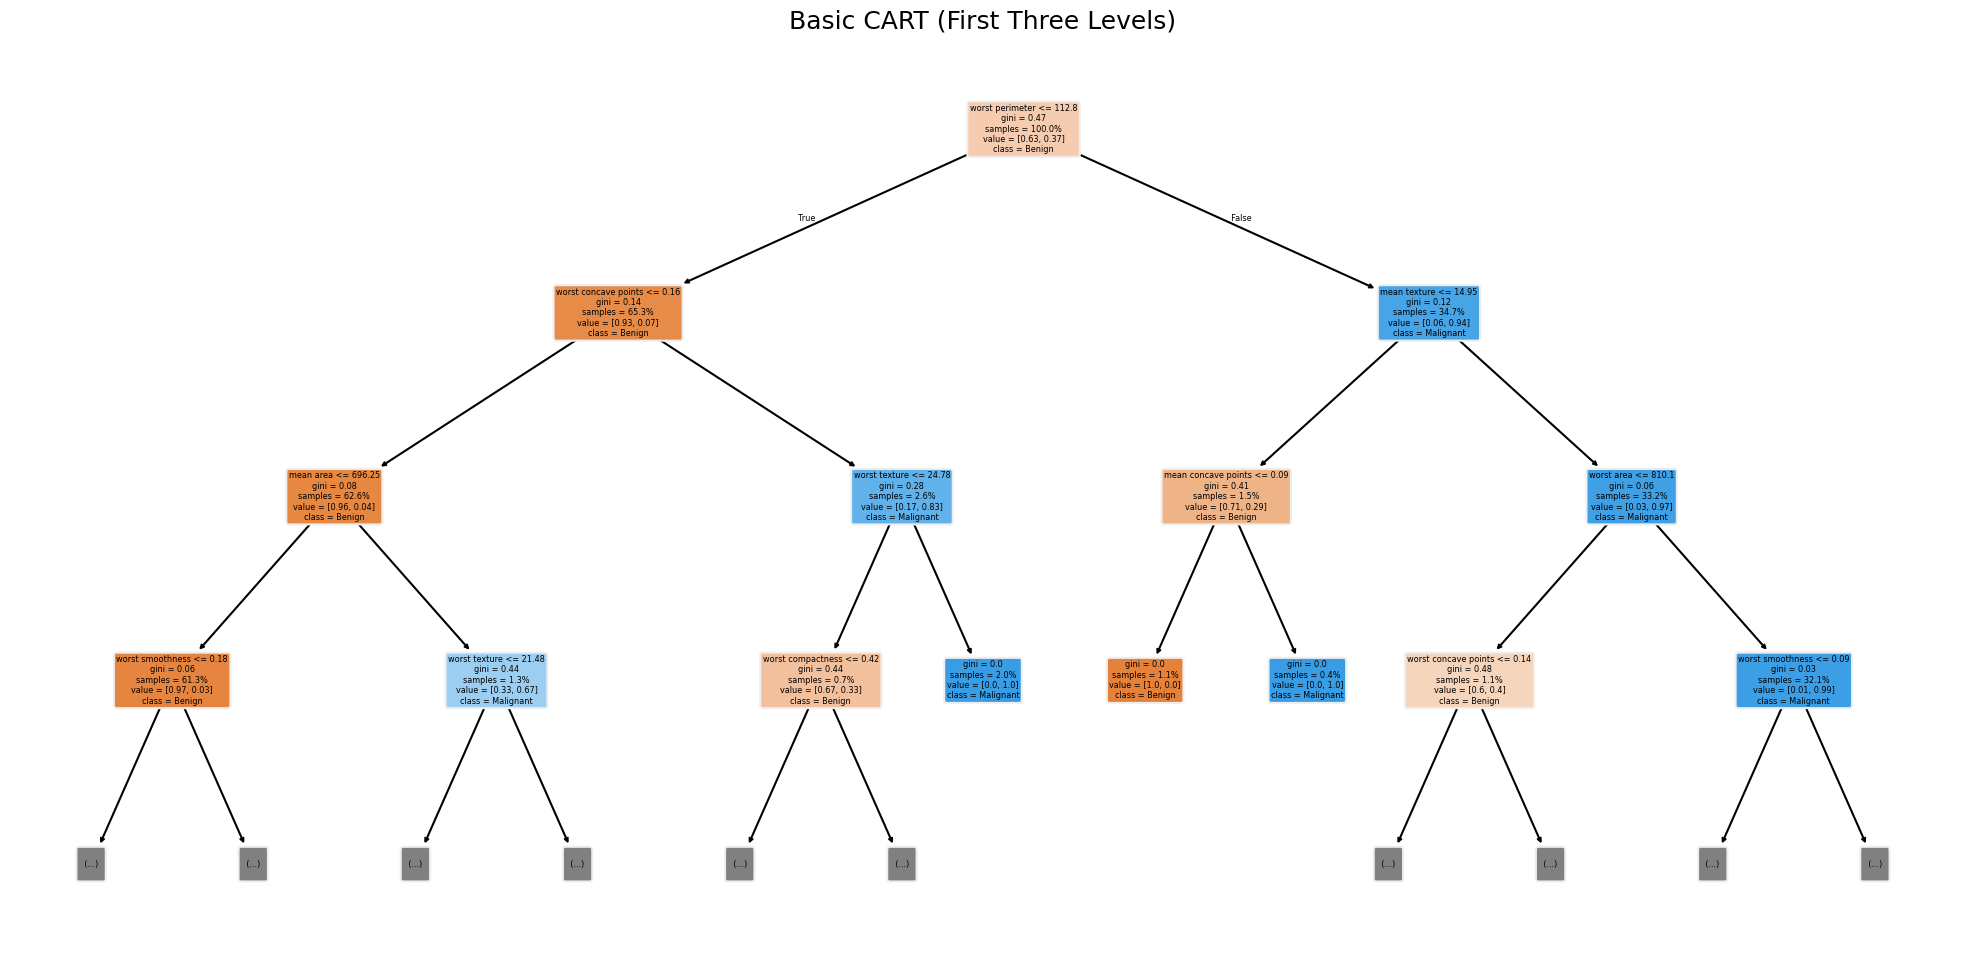

In [49]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(

    tree,

    feature_names=X.columns,

    class_names=[

        "Benign",

        "Malignant"

    ],

    filled=True,

    rounded=True,

    proportion=True,

    precision=2,

    max_depth=3

)

plt.title("Basic CART (First Three Levels)")

plt.tight_layout()

plt.show()

In [50]:
from sklearn.tree import export_text
rules = export_text(

    tree,

    feature_names=list(X.columns)

)

print(rules[:5000])

|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.16
|   |   |--- mean area <= 696.25
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- worst perimeter <= 102.40
|   |   |   |   |   |--- area error <= 47.03
|   |   |   |   |   |   |--- worst texture <= 33.35
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- worst texture >  33.35
|   |   |   |   |   |   |   |--- mean texture <= 23.20
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- mean texture >  23.20
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- area error >  47.03
|   |   |   |   |   |   |--- concavity error <= 0.02
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- concavity error >  0.02
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- worst perimeter >  102.40
|   |   |   |   |   |--- worst smoothness <= 0.14
|   |   |   |   |   |   |--- worst perimeter <= 102.70
|   |   |   |   |   |   |   |

In [51]:
comparison_df = (

    pd.DataFrame(model_comparison)

      .sort_values(

          by="ROC-AUC",

          ascending=False

      )

)

comparison_df.round(4)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Basic CART,0.9231,0.9172,0.8996,0.8941,0.8962,0.9172,0.8453
0,Dummy Baseline,0.6264,0.5000,0.0000,0.0000,0.0000,0.5000,0.3736


# 8. Model Development – Advanced Tree Models

We will define helper functions for tuning and pruning. Then we will tune a CART with pre-pruning hyperparameters, and subsequently select ccp_alpha via cross-validation. Finally, we will tune a Random Forest.

In [52]:
# =============================================================================
# Define Modular Tuning Functions
# =============================================================================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def tune_model(pipeline, param_grid, X, y, cv, scoring, refit='roc_auc', 
               n_jobs=-1, return_train_score=True, search_type='grid'):
    """
    Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
    
    Parameters:
        pipeline: sklearn Pipeline or estimator
        param_grid: dict of parameters to search
        X, y: training data
        cv: cross-validation object
        scoring: dict of scoring metrics
        refit: metric to select best model
        n_jobs: parallel jobs
        return_train_score: bool
        search_type: 'grid' or 'random'
    
    Returns:
        best_estimator, best_params, cv_results_df, best_score
    """
    if search_type == 'grid':
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=scoring,
            refit=refit,
            cv=cv,
            n_jobs=n_jobs,
            return_train_score=return_train_score,
            verbose=1
        )
    else:
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            scoring=scoring,
            refit=refit,
            cv=cv,
            n_jobs=n_jobs,
            return_train_score=return_train_score,
            n_iter=50,  # default for random
            verbose=1,
            random_state=RANDOM_STATE
        )
    search.fit(X, y)
    cv_results = pd.DataFrame(search.cv_results_)
    return search.best_estimator_, search.best_params_, cv_results, search.best_score_

In [53]:
# =============================================================================
# Tune Pre-pruned CART (Grid Search over pre-pruning hyperparameters)
# =============================================================================
# Build a pipeline with the imputer and a DecisionTreeClassifier
cart_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Define search space for pre-pruning
param_grid_cart = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 4, 5, 6, 8, 10, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__class_weight': [None, 'balanced']
}

print("Tuning CART pre-pruning hyperparameters...")
best_cart_estimator, best_cart_params, cart_cv_results, best_cart_score = tune_model(
    pipeline=cart_pipe,
    param_grid=param_grid_cart,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=SCORING,
    refit='ROC-AUC',
    search_type='grid'
)

print("\nBest pre-pruned CART parameters:")
print(best_cart_params)
print(f"Best cv ROC-AUC: {best_cart_score:.4f}")

Tuning CART pre-pruning hyperparameters...
Fitting 5 folds for each of 448 candidates, totalling 2240 fits

Best pre-pruned CART parameters:
{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Best cv ROC-AUC: 0.9754


### Observation:
The grid search will choose the combination of max_depth, min_samples_split, min_samples_leaf, criterion, and class_weight that maximizes cross-validated ROC‑AUC. This pre-pruned tree already reduces overfitting compared to the unconstrained CART.

# 9. Cost-Complexity Pruning for CART
Now we will use the best hyperparameters found above (excluding ccp_alpha) and then select the optimal ccp_alpha via cross-validation.

In [54]:
# =============================================================================
# Cost-Complexity Pruning (ccp_alpha selection)
# =============================================================================
# First, train a base tree on the full training data using the best pre-pruning params
# (without ccp_alpha) to obtain the pruning path.
base_tree = DecisionTreeClassifier(
    criterion=best_cart_params['model__criterion'],
    max_depth=best_cart_params['model__max_depth'],
    min_samples_split=best_cart_params['model__min_samples_split'],
    min_samples_leaf=best_cart_params['model__min_samples_leaf'],
    class_weight=best_cart_params['model__class_weight'],
    random_state=RANDOM_STATE
)
base_tree.fit(X_train, y_train)

# Compute cost-complexity pruning path
path = base_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path["ccp_alphas"]
impurities = path["impurities"]
# Remove the trivial tree (alpha = 0) and large alpha values that yield single node
ccp_alphas = np.asarray(ccp_alphas, dtype=float)
ccp_alphas = ccp_alphas[ccp_alphas > 0]

if len(ccp_alphas) == 0:
    ccp_alphas = np.array([0.0], dtype=float)

# We'll create a pipeline with the same pre-processing and set model with best params,
# then tune ccp_alpha
prune_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(
        criterion=best_cart_params['model__criterion'],
        max_depth=best_cart_params['model__max_depth'],
        min_samples_split=best_cart_params['model__min_samples_split'],
        min_samples_leaf=best_cart_params['model__min_samples_leaf'],
        class_weight=best_cart_params['model__class_weight'],
        random_state=RANDOM_STATE
    ))
])

# Use a reduced set of alphas to speed up (e.g., take 20 evenly spaced)
if len(ccp_alphas) > 20:
    alpha_grid = np.linspace(ccp_alphas.min(), ccp_alphas.max(), 20)
else:
    alpha_grid = ccp_alphas

param_grid_alpha = {
    'model__ccp_alpha': alpha_grid
}

print("Tuning ccp_alpha via cross-validation...")
best_pruned_estimator, best_alpha_params, alpha_cv_results, best_alpha_score = tune_model(
    pipeline=prune_pipe,
    param_grid=param_grid_alpha,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=SCORING,
    refit='ROC-AUC',
    search_type='grid'
)

best_ccp_alpha = best_alpha_params['model__ccp_alpha']
print(f"\nBest ccp_alpha: {best_ccp_alpha:.6f}")
print(f"Best cv ROC-AUC after pruning: {best_alpha_score:.4f}")

# The best_pruned_estimator now contains the tuned and pruned CART
pruned_cart = best_pruned_estimator

Tuning ccp_alpha via cross-validation...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best ccp_alpha: 0.000851
Best cv ROC-AUC after pruning: 0.9702


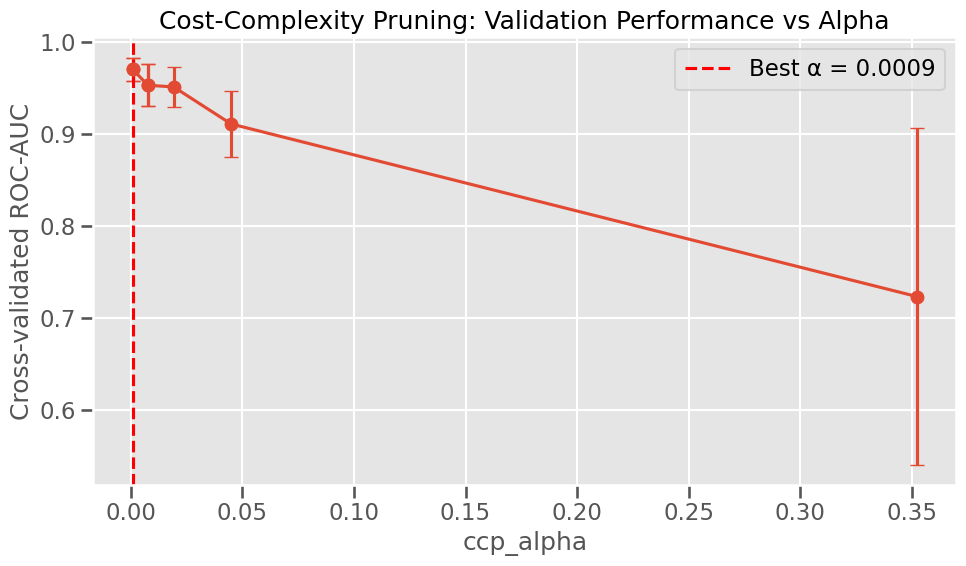

In [55]:
# Plot CV score vs ccp_alpha
alpha_vals = alpha_cv_results["param_model__ccp_alpha"].astype(float).values

mean_col = next(
    c for c in alpha_cv_results.columns
    if c.startswith("mean_test_") and "roc" in c.lower()
)
std_col = next(
    c for c in alpha_cv_results.columns
    if c.startswith("std_test_") and "roc" in c.lower()
)

mean_test_scores = alpha_cv_results[mean_col].astype(float).values
std_test_scores = alpha_cv_results[std_col].astype(float).values

plt.figure(figsize=(10, 6))
plt.errorbar(alpha_vals, mean_test_scores, yerr=std_test_scores, fmt='o-', capsize=5)
plt.axvline(best_ccp_alpha, color='red', linestyle='--', label=f'Best α = {best_ccp_alpha:.4f}')
plt.xlabel('ccp_alpha')
plt.ylabel('Cross-validated ROC-AUC')
plt.title('Cost-Complexity Pruning: Validation Performance vs Alpha')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Tune Random Forest
We will tune a Random Forest using a randomized search over a wide range of hyperparameters, then refine with grid search if needed.

In [56]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

# Define a broad search space (randomized search first)
param_dist_rf = {
    'model__n_estimators': [100, 300, 500, 700],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.3, 0.5],
    'model__class_weight': [None, 'balanced']
}

print("Tuning Random Forest with randomized search...")
best_rf_estimator, best_rf_params, rf_cv_results, best_rf_score = tune_model(
    pipeline=rf_pipe,
    param_grid=param_dist_rf,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=SCORING,
    refit='ROC-AUC',
    search_type='random'  # use randomized search for efficiency
)

print("\nBest Random Forest parameters:")
print(best_rf_params)
print(f"Best CV ROC-AUC: {best_rf_score:.4f}")

Tuning Random Forest with randomized search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 5, 'model__class_weight': 'balanced'}
Best CV ROC-AUC: 0.9909


# 11. Model Comparison (Cross-Validation)
Now we compare all models: Dummy, Basic CART, Tuned & Pruned CART, and Random Forest. We'll use the cv_report function you already defined (or we can enhance it to return a full summary). We'll collect the results in a DataFrame.

In [57]:
# Re-instantiate models for comparison (using best selected ones)
models_to_compare = {
    'Dummy Baseline': DummyClassifier(strategy='prior'),
    'Basic CART': DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE),
    'Tuned & Pruned CART': pruned_cart,
    'Random Forest': best_rf_estimator
}

# Use your existing cv_report function to get summary and rows
comparison_rows = []
comparison_summaries = {}

for name, model in models_to_compare.items():
    print(f"Evaluating {name}...")
    # We'll use the same SCORING dictionary
    # Note: cv_report expects model, model_name, X, y, cv, scoring, return_predictions
    # We'll call it and append the row
    summary, row = cv_report(model, name, X_train, y_train, cv, SCORING, return_predictions=False)
    comparison_summaries[name] = summary
    comparison_rows.append(row)

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).round(4)
comparison_df

Evaluating Dummy Baseline...
Evaluating Basic CART...
Evaluating Tuned & Pruned CART...
Evaluating Random Forest...


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Random Forest,0.9626,0.9583,0.9596,0.9412,0.9494,0.9909,0.9883
2,Tuned & Pruned CART,0.9429,0.9437,0.9068,0.9471,0.9255,0.9702,0.9334
1,Basic CART,0.9231,0.9172,0.8996,0.8941,0.8962,0.9172,0.8453
0,Dummy Baseline,0.6264,0.5000,0.0000,0.0000,0.0000,0.5000,0.3736


## 11.1 Model Comparison Visualization
Bar chart comparing models across key metrics (ROC-AUC, PR-AUC, Balanced Accuracy, F1).

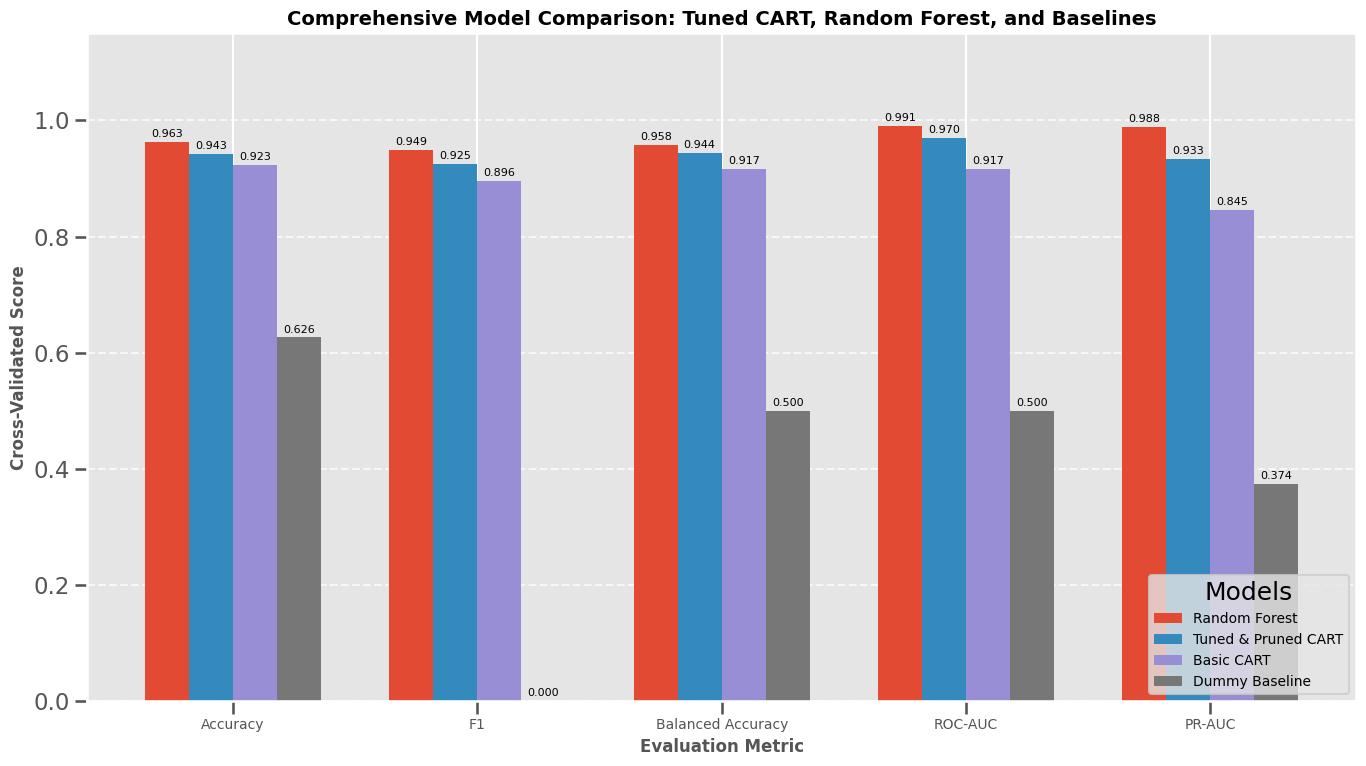

In [58]:
# ==========================================
# Comprehensive Model Comparison Bar Chart
# Comparing Dummy, Basic CART, Tuned & Pruned CART, and Random Forest
# ==========================================

plot_metrics = ["Accuracy", "F1", "Balanced Accuracy", "ROC-AUC", "PR-AUC"]

x = np.arange(len(plot_metrics))
width = 0.18
multiplier = 0

fig, ax = plt.subplots(figsize=(14, 8))

for i, row in comparison_df.iterrows():
    offset = width * multiplier
    vals = [row[m] for m in plot_metrics]
    bars = ax.bar(x + offset, vals, width, label=row["Model"])
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=0)
    multiplier += 1

ax.set_xlabel("Evaluation Metric", fontsize=12, fontweight="bold")
ax.set_ylabel("Cross-Validated Score", fontsize=12, fontweight="bold")
ax.set_title("Comprehensive Model Comparison: Tuned CART, Random Forest, and Baselines", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_metrics, fontsize=10)
ax.legend(loc="lower right", fontsize=10, title="Models")
ax.set_ylim(0, 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


### Observation:
The comparison table shows the mean and standard deviation of each metric across the 5 folds. The Random Forest is expected to have the highest ROC‑AUC and PR‑AUC, while the Tuned & Pruned CART balances performance and interpretability.

# 12. Select Operating Threshold
We will choose the final model (e.g., the one with the best cross-validated ROC‑AUC, or the most interpretable if performance is similar). For this notebook, we will select the Tuned & Pruned CART because of its interpretability, but you may choose the Random Forest if performance is considerably better. We'll demonstrate threshold selection using out-of-fold predictions from the chosen model.

Selected threshold (max Youden): 0.475
Selected threshold (target sensitivity >= 0.95): 0.475


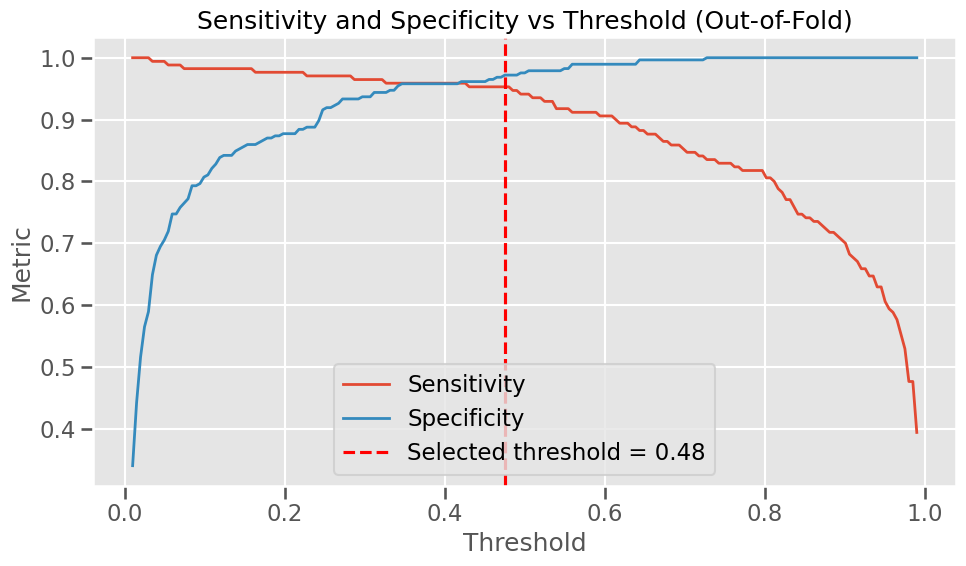

In [59]:
final_model = best_rf_estimator   # or pruned_cart for interpretability

# Generate out-of-fold probabilities on the training set
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# Evaluate thresholds
thresholds = np.linspace(0.01, 0.99, 199)
threshold_metrics = []
for thresh in thresholds:
    pred = (oof_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    threshold_metrics.append({
        'threshold': thresh,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'youden': sensitivity + specificity - 1
    })

threshold_df = pd.DataFrame(threshold_metrics)

# Choose threshold that maximizes Youden's index (or enforce a minimum sensitivity)
# For educational demonstration, we'll choose max Youden
best_youden_idx = threshold_df['youden'].idxmax()
selected_threshold = threshold_df.loc[best_youden_idx, 'threshold']
print(f"Selected threshold (max Youden): {selected_threshold:.3f}")

# Alternatively, enforce a target sensitivity (e.g., 0.95) as per lab manual
TARGET_SENSITIVITY = 0.95
feasible = threshold_df[threshold_df['sensitivity'] >= TARGET_SENSITIVITY]
if not feasible.empty:
    selected_threshold = feasible.sort_values('specificity', ascending=False).iloc[0]['threshold']
    print(f"Selected threshold (target sensitivity >= {TARGET_SENSITIVITY}): {selected_threshold:.3f}")
else:
    print("No threshold meets the target sensitivity; using max Youden.")

# Plot threshold curves
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['threshold'], threshold_df['sensitivity'], label='Sensitivity', linewidth=2)
plt.plot(threshold_df['threshold'], threshold_df['specificity'], label='Specificity', linewidth=2)
plt.axvline(selected_threshold, color='red', linestyle='--', label=f'Selected threshold = {selected_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.title('Sensitivity and Specificity vs Threshold (Out-of-Fold)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13. Final Evaluation on Test Set
Now we lock the model and evaluate it on the test set once. We will use the selected threshold.

In [60]:
# Fit the final model on the entire training set (with best parameters)
final_model.fit(X_train, y_train)

# Predict probabilities on test set
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= selected_threshold).astype(int)

# Compute metrics using a function
def evaluate_binary(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {
        'threshold': selected_threshold,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'npv': tn / (tn + fn) if (tn + fn) > 0 else 0,
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'pr_auc': average_precision_score(y_true, y_proba),
        'brier_score': brier_score_loss(y_true, y_proba)
    }
    return metrics

test_metrics = evaluate_binary(y_test, test_pred, test_proba)
test_metrics_df = pd.DataFrame([test_metrics]).round(4)
test_metrics_df

,threshold,TN,FP,FN,TP,accuracy,balanced_accuracy,sensitivity,specificity,precision,npv,f1,mcc,roc_auc,pr_auc,brier_score
0,0.4753,71,1,3,39,0.9649,0.9573,0.9286,0.9861,0.9750,0.9595,0.9512,0.9245,0.9983,0.9972,0.0272


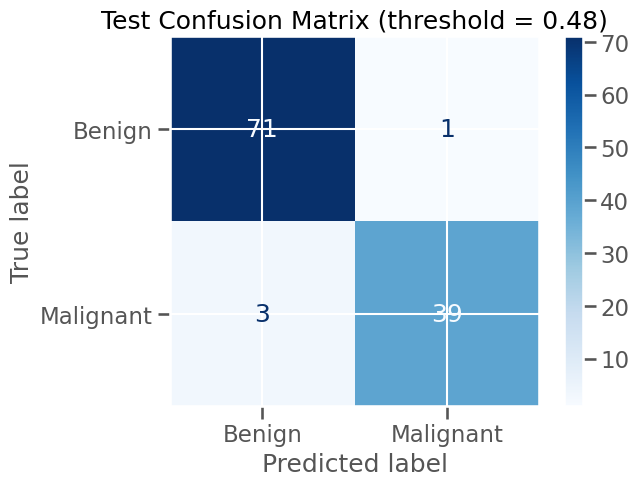

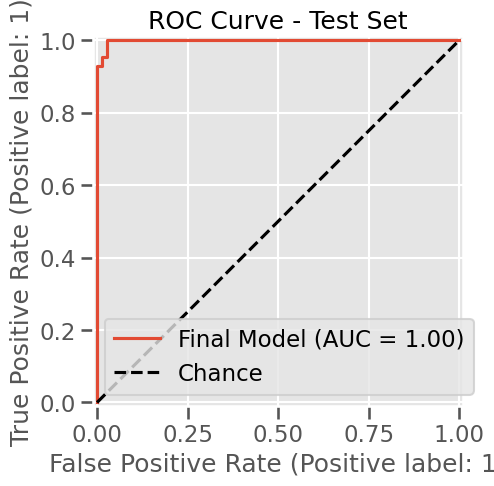

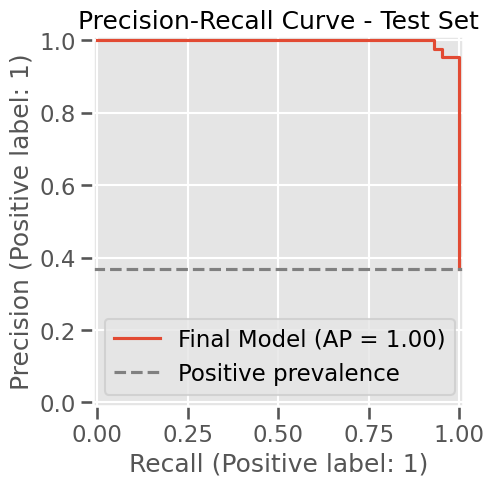

In [61]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred,
    display_labels=['Benign', 'Malignant'],
    cmap='Blues',
    values_format='d'
)
plt.title(f'Test Confusion Matrix (threshold = {selected_threshold:.2f})')
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, test_proba, name='Final Model')
plt.plot([0,1], [0,1], 'k--', label='Chance')
plt.legend()
plt.title('ROC Curve - Test Set')
plt.show()

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test, test_proba, name='Final Model')
plt.axhline(y_test.mean(), color='gray', linestyle='--', label='Positive prevalence')
plt.legend()
plt.title('Precision-Recall Curve - Test Set')
plt.show()

# 14. Save Artifacts

## 13.4 Calibration Plot (Reliability Diagram)
Evaluate probability calibration of the final model on the test set.

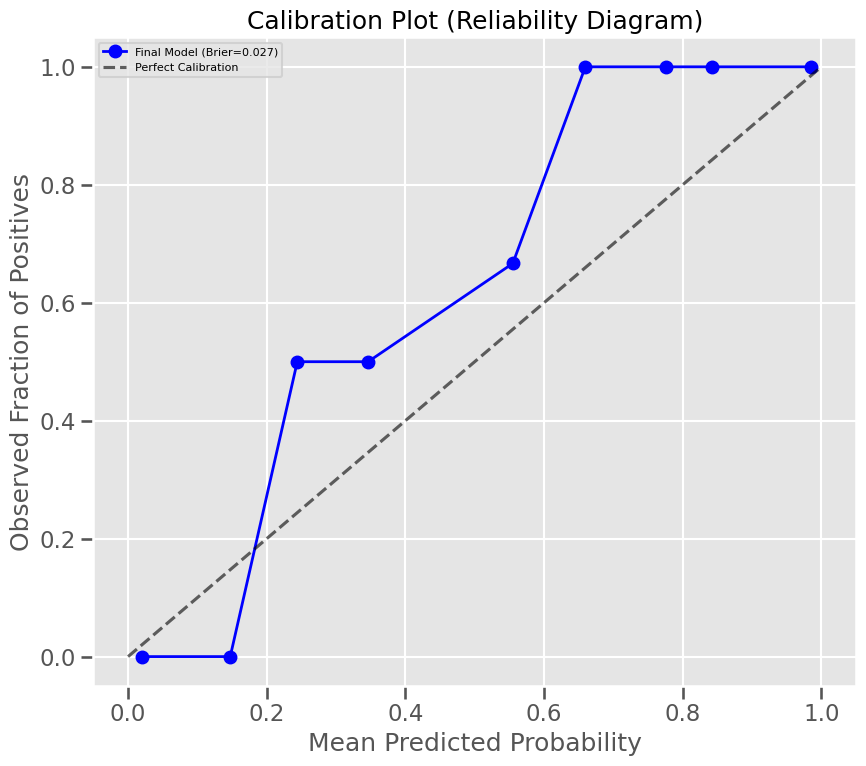

In [63]:
from sklearn.calibration import calibration_curve

def plot_calibration(y_true, prob, model_name, ax, color):
    prob_true, prob_pred = calibration_curve(y_true, prob, n_bins=10, strategy="uniform")
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label=model_name, color=color)

fig, ax = plt.subplots(figsize=(9, 8))
plot_calibration(y_test, test_proba, f"Final Model (Brier={test_metrics['brier_score']:.3f})", ax, "blue")
ax.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", alpha=0.6)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction of Positives")
ax.set_title("Calibration Plot (Reliability Diagram)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.show()


In [64]:
from pathlib import Path
import joblib
import platform
import sklearn

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

artifact_bundle = {
    "preprocessor": preprocessor,
    "dummy_pipeline": dummy_pipeline,
    "basic_cart_pipeline": basic_cart,
    "cart_tuning_pipeline": cart_pipe,
    "best_cart_pipeline": best_cart_estimator,
    "pruning_pipeline": prune_pipe,
    "pruned_cart_pipeline": pruned_cart,
    "random_forest_pipeline": rf_pipe,
    "best_random_forest_pipeline": best_rf_estimator,
    "final_model": final_model,
    "threshold": selected_threshold,
    "positive_class": "malignant",
    "feature_names": list(X_train.columns),
    "random_state": RANDOM_STATE,
    "test_metrics": test_metrics,
    "software": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__
    },
    "intended_use": "Educational predictive-analytics laboratory only",
    "prohibited_use": "Clinical diagnosis, treatment, triage, or patient management"
}

joblib.dump(artifact_bundle, artifacts_dir / "lab02_full_artifact_bundle.joblib")

# Save each major fitted object separately as well
for name, obj in artifact_bundle.items():
    if isinstance(obj, (dict, list, str, int, float, bool)):
        continue
    joblib.dump(obj, artifacts_dir / f"{name}.joblib")

pd.DataFrame([test_metrics]).to_csv(artifacts_dir / "lab02_test_metrics.csv", index=False)
print("Artifacts saved to:", artifacts_dir)
print("Saved bundle:", artifacts_dir / "lab02_full_artifact_bundle.joblib")

Artifacts saved to: artifacts
Saved bundle: artifacts\lab02_full_artifact_bundle.joblib
